# **Sprint 3 — Inteligência Conversacional TOTVS**

---

## Integrantes
* Diogo Pelinson Duarte de Morais, RM563321
* Jessica Vitória Tavares, RM566220
* Luara Freire Soares, RM561266
* Miguel Amaro Dourado de Sousa, RM566200
* Pedro Henrique Caires da Silva, RM562344

---

## Objetivo

Desenvolver modelos de Machine Learning supervisionado para classificar transcrições de atendimentos em três categorias relevantes para o negócio:

- risco de churn;
- oportunidade de upsell;
- menção a concorrente.

Cada categoria é tratada como uma classificação binária: presença (`1`) ou ausência (`0`) do respectivo sinal.

In [375]:
# Import de Dependências
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [376]:
# Leitura dos dataset de treino e de teste
# df é o dataset tratado na sprint anterior
df = pd.read_csv('https://raw.githubusercontent.com/group-infinity/Sprint-3---Data-Science/refs/heads/main/data/df_filtrado.csv')
# df_teste é um novo dataset para teste dos modelos após o treino
df_teste = pd.read_excel('https://raw.githubusercontent.com/group-infinity/Sprint-3---Data-Science/refs/heads/main/data/lote_teste_transcricoes.xlsx')

# Import local por arquivo, disponível no Github (https://github.com/group-infinity/Sprint-3---Data-Science/tree/main/data)
# df = pd.read_csv('/content/df_filtrado.csv')
# df_teste = pd.read_excel('/content/lote_teste_transcricoes.xlsx')

In [377]:
# Captura das transcrições do dataset de treinos
transcricoes = df.loc[:, 'transcricao']
mensagens = transcricoes.tolist()

# Estruturação do dataset utilizado ao longo do notebook
campos_modelo = ('model', 'targets', 'metrics', 'predictions')
tipos = {
    'churn': 'risco_de_churn',
    'upsell': 'oportunidade_upsell',
    'concorrente': 'mencao_concorrente',
}

config = {
    nome: {
        'classes': df[tipo].tolist(),
        'models': {
            modelo: {campo: None for campo in campos_modelo}
            for modelo in ('naive_bayes', 'random_forest')
        },
        'vetorizer': CountVectorizer()
    }
    for nome, tipo in tipos.items()
}

## Análise das classes e balanceamento

Foram analisadas as distribuições das classes `0` (ausência do indicador) e `1` (presença do indicador) para churn, upsell e menção a concorrente.

Como os modelos utilizados possuem divisão estratificada (`stratify=y`), a proporção das classes é preservada entre treino e teste.

In [378]:
# Análise dos rótulos classificados do dataset de treino
for tipo, coluna in tipos.items():
    print(f'\n{tipo.upper()}')
    print(df[coluna].value_counts())


CHURN
risco_de_churn
0    583
1    417
Name: count, dtype: int64

UPSELL
oportunidade_upsell
0    554
1    446
Name: count, dtype: int64

CONCORRENTE
mencao_concorrente
0    701
1    299
Name: count, dtype: int64


In [379]:
# Transcrição para teste dos modelos recém-treinados
transcricao_teste = ["Durante a reunião com empresa do setor de logística, de porte pequena, o cliente relatou que utiliza principalmente o módulo de bi. Demonstrou abertura para piloto com dashboard gerencial. Além disso, a equipe alinhou cronograma para nova rodada de testes. Relatou que um concorrente ofereceu condições comerciais mais vantajosas para o mesmo escopo. O cliente espera melhoria perceptível antes de ampliar o escopo."]

## Preparação dos dados

Os dados foram separados entre treino e teste na proporção de 67% e 33%, respectivamente. Foi utilizado `stratify=y` para preservar a proporção das classes nos dois conjuntos e `random_state=33` para garantir a reprodutibilidade dos resultados.

Os textos foram convertidos em vetores com `CountVectorizer`

In [380]:
def get_tipo_rotulo(tipo_rotulo):
    match tipo_rotulo:
        case 'churn':
            return ["Sem risco de churn", "Risco de churn"]
        case 'upsell':
            return ["Sem oportunidade de upsell", "Oportunidade de Upsell"]
        case 'concorrente':
            return ["Sem menção a concorrente", "Menção a concorrente"]

In [381]:
# Treinamento dos modelos
def train_model(mensagens, classes, modelo, tipo, vetorizador):
    y = np.array(classes)

    # Divisão dos textos
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        mensagens,
        y,
        test_size=0.33,
        random_state=33,
        stratify=y
    )

    # Vetorização dos textos
    X_treino_vetorizado = vetorizador.fit_transform(X_treino)
    X_teste_vetorizado = vetorizador.transform(X_teste)

    # Treinamento
    modelo.fit(X_treino_vetorizado, y_treino)
    # Predição
    previsoes = modelo.predict(X_teste_vetorizado)

    # Extraindo métricas para uso futuro
    targets = get_tipo_rotulo(tipo)
    metrics = classification_report(y_teste, previsoes, target_names=targets, output_dict=True)
    model_name = 'naive_bayes' if isinstance(modelo, MultinomialNB) else 'random_forest'

    # Armazenando métricas
    config[tipo]['models'][model_name]['metrics'] = metrics

    # Output
    print(f'{'*' * 20} MODELO {targets[1].upper()} {'*' * 20}')
    print(f"Acurácia do Modelo: {accuracy_score(y_teste, previsoes) * 100:.2f}%")
    print("\nRelatório de Classificação:")
    print(classification_report(y_teste, previsoes, target_names=targets))

    return modelo, targets

## Modelos avaliados

Foram comparados dois algoritmos de classificação:

- **Naive Bayes:** modelo frequentemente usado como baseline para classificação de textos.
- **Random Forest:** conjunto de árvores de decisão capaz de modelar relações mais complexas entre os atributos.

Os modelos foram treinados separadamente para churn, upsell e menção a concorrente.

In [382]:
def run_train_model(criar_modelo):
    for k, v in config.items():
        # Iniciando um modelo para cada tipo de treino
        modelo_treino = criar_modelo()
        vetorizador = v['vetorizer']

        # Realizando treino
        modelo, targets = train_model(mensagens, v['classes'], modelo_treino, k, vetorizador)
        model_name = 'naive_bayes' if isinstance(modelo, MultinomialNB) else 'random_forest'

        # Armazenando o modelo e os targets
        v['models'][model_name]['model'] = modelo
        v['models'][model_name]['targets'] = targets

        # Vetorizando textos e fazendo a predição da transcrição teste
        transcricao_teste_vetorizada = vetorizador.transform(transcricao_teste)
        predicao_nova = modelo.predict(transcricao_teste_vetorizada)

        classe_final = targets[1] if predicao_nova[0] == 1 else targets[0]

        # Output
        print(f"\nNova mensagem: '{transcricao_teste[0][:100]}...' \n Classificada como: **{classe_final}**")
        print('\n\n')

## Métricas de avaliação

Foram utilizadas as seguintes métricas:

- **Accuracy:** proporção total de classificações corretas.
- **Precision:** entre as previsões positivas, quantas realmente eram positivas.
- **Recall:** entre os casos realmente positivos, quantos foram identificados pelo modelo.
- **F1-score:** média harmônica entre precision e recall.

Para **churn**, o recall da classe positiva é especialmente importante, pois um falso negativo pode impedir uma ação preventiva para reter um cliente em risco.

Para **upsell**, a precision é relevante para reduzir abordagens comerciais desnecessárias.

Para **menção a concorrente**, o recall ajuda a não perder sinais competitivos que podem exigir acompanhamento.

## Algoritmo Naive Bayes

In [383]:
run_train_model(lambda: MultinomialNB())

******************** MODELO RISCO DE CHURN ********************
Acurácia do Modelo: 96.06%

Relatório de Classificação:
                    precision    recall  f1-score   support

Sem risco de churn       0.97      0.96      0.97       192
    Risco de churn       0.95      0.96      0.95       138

          accuracy                           0.96       330
         macro avg       0.96      0.96      0.96       330
      weighted avg       0.96      0.96      0.96       330


Nova mensagem: 'Durante a reunião com empresa do setor de logística, de porte pequena, o cliente relatou que utiliza...' 
 Classificada como: **Sem risco de churn**



******************** MODELO OPORTUNIDADE DE UPSELL ********************
Acurácia do Modelo: 91.21%

Relatório de Classificação:
                            precision    recall  f1-score   support

Sem oportunidade de upsell       0.93      0.91      0.92       183
    Oportunidade de Upsell       0.89      0.91      0.90       147

              

## Algoritmo Random Forest

In [384]:
run_train_model(lambda: RandomForestClassifier(
    n_estimators=100, max_depth=10, max_features='sqrt', random_state=33
))

******************** MODELO RISCO DE CHURN ********************
Acurácia do Modelo: 94.24%

Relatório de Classificação:
                    precision    recall  f1-score   support

Sem risco de churn       0.91      0.99      0.95       192
    Risco de churn       0.99      0.87      0.93       138

          accuracy                           0.94       330
         macro avg       0.95      0.93      0.94       330
      weighted avg       0.95      0.94      0.94       330


Nova mensagem: 'Durante a reunião com empresa do setor de logística, de porte pequena, o cliente relatou que utiliza...' 
 Classificada como: **Sem risco de churn**



******************** MODELO OPORTUNIDADE DE UPSELL ********************
Acurácia do Modelo: 98.48%

Relatório de Classificação:
                            precision    recall  f1-score   support

Sem oportunidade de upsell       0.98      0.99      0.99       183
    Oportunidade de Upsell       0.99      0.97      0.98       147

              

## Resultados

| Alvo | Naive Bayes | Random Forest | Modelo com melhor resultado |
|---|---:|---:|---|
| Risco de churn | 96,06% | 94,24% | Naive Bayes |
| Oportunidade de upsell | 91,21% | 98,48% | Random Forest |
| Menção a concorrente | 99,39% | 99,70% | Random Forest |

O Naive Bayes apresentou melhor desempenho para identificar risco de churn, incluindo maior recall para a classe positiva. O Random Forest apresentou melhor resultado para upsell e menção a concorrente.


## Confusion Matrix

As Confusion Matrix são geradas separadamente para cada alvo e cada algoritmo. Essa abordagem preserva a natureza multilabel do problema: uma mesma transcrição pode, simultaneamente, indicar churn, oportunidade de upsell e menção a concorrente.

\
A Confusion Matrix é realizada a partir de um novo dataset de transcrições, o `df_teste`

In [385]:
# Capturando as transcrições do dataset de teste
transcricoes_teste_list = df_teste.loc[:, 'transcricao'].tolist()

In [386]:
def run_models(mensagens, modelo, model_name, vetorizador, tipo):
    # Vetorização e predição
    transcricao_vetorizada = vetorizador.transform(mensagens)
    predicao_nova = modelo.predict(transcricao_vetorizada)

    # Identifica a classe do modelo para saber em qual lista salvar
    config[tipo]['models'][model_name]['predictions'] = predicao_nova

In [387]:
for k, v in config.items():
    # Roda cada modelo para capturar as predições e usar na Confusion Matrix
    for model, atributo in v['models'].items():
        run_models(
            mensagens=transcricoes_teste_list,
            modelo=atributo['model'],
            model_name=model,
            vetorizador=v['vetorizer'],
            tipo=k
        )

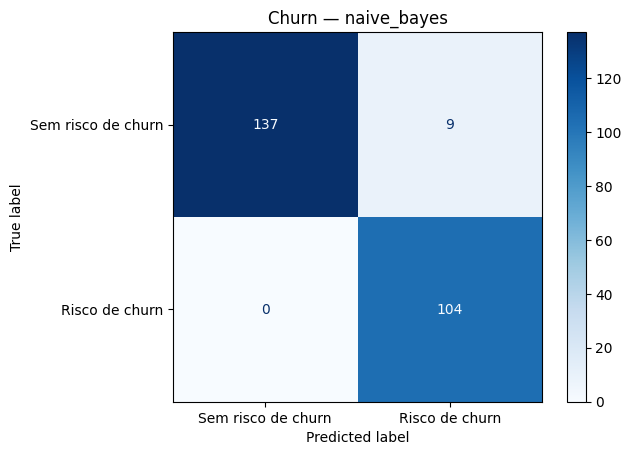

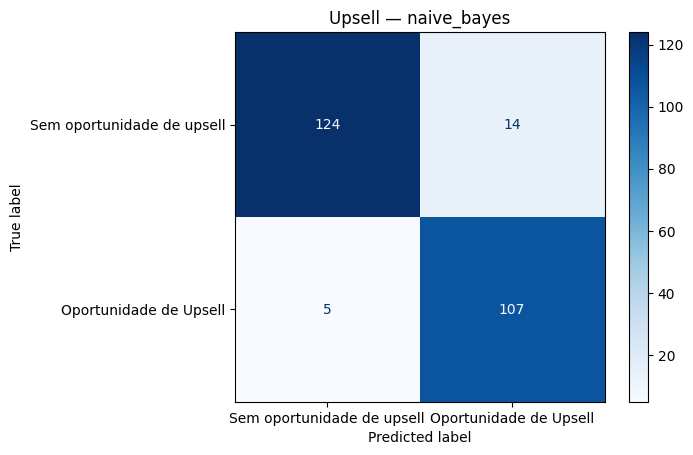

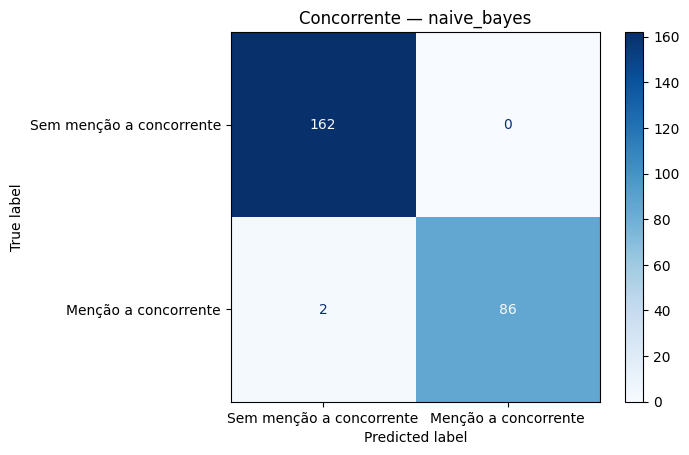

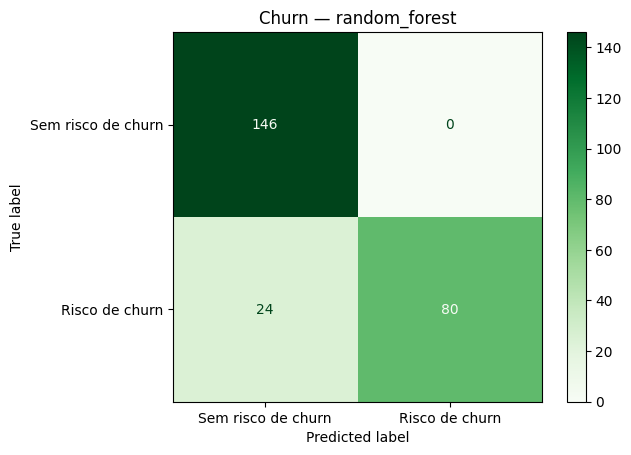

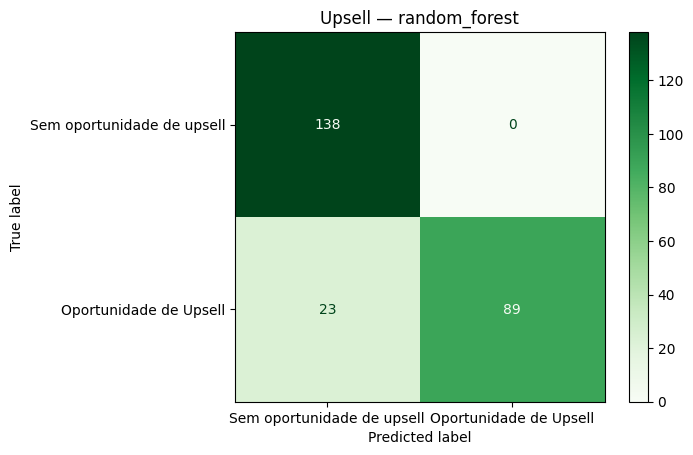

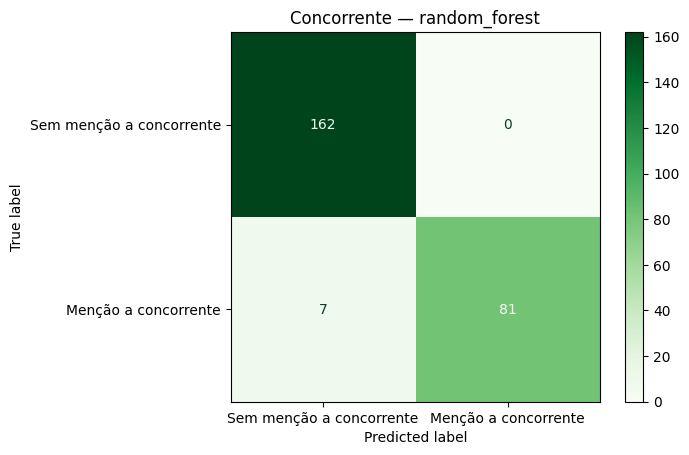

In [388]:
# Faz o plot da Confusion Matrix para cada modelo treinado
for nome_modelo in ('naive_bayes', 'random_forest'):
    for tipo, coluna in tipos.items():
        y_real = df_teste[coluna]
        y_pred = config[tipo]['models'][nome_modelo]['predictions']

        cm = confusion_matrix(y_real, y_pred, labels=[0, 1])
        cor = plt.cm.Blues if nome_modelo == 'naive_bayes' else plt.cm.Greens

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=config[tipo]['models'][nome_modelo]['targets']
        ).plot(cmap=cor)

        plt.title(f'{tipo.title()} — {nome_modelo}')
        plt.show()

## Conclusão e implicações para o negócio

Os modelos foram capazes de classificar as transcrições nos três objetivos analisados: risco de churn, oportunidade de upsell e menção a concorrente.

O Naive Bayes apresentou o melhor resultado para churn, enquanto o Random Forest apresentou melhor desempenho para upsell e menção a concorrente. Dessa forma, os modelos podem apoiar o time de negócio na priorização de ações de retenção, identificação de oportunidades comerciais e monitoramento de concorrentes.

Como próximos passos, validar os modelos periodicamente com novas transcrições e analisar os casos incorretos para aperfeiçoar os dados e o processo de classificação.